In [1]:
# --- 导入深度学习核心库与可视化工具 ---
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
from keras import layers, Sequential
from keras.layers import RandomFlip, RandomRotation
import matplotlib.pyplot as plt

# Keras 3 中 image_dataset_from_directory 位于 tf.keras.utils
# （旧写法 from keras.preprocessing import ... 在部分 Keras 3 版本会报错）
image_dataset_from_directory = tf.keras.utils.image_dataset_from_directory

# --- 全局参数配置 ---
BATCH_SIZE = 32       # 每一批次训练 32 张图像，平衡内存消耗与梯度更新频率
IMG_SIZE = (160, 160) # 统一图像尺寸，适配 MobileNetV2 的标准输入要求


I0000 00:00:1790055537.807392    3898 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790055537.811655    3898 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790055538.290654    3898 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790055541.393937    3898 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

> --- 数据集目录：优先 Kaggle 路径，其次本地压缩包 ---
> 
> KAGGLE_DIR = "/kaggle/input/alpaca-dataset-small/dataset"
> 
>  alpaca-dataset-small.zip 压缩包路径需要自行下载并且重命名为alpaca-dataset-small.zip
> 
> https://www.kaggle.com/datasets/sid4sal/alpaca-dataset-small

In [4]:

# --- 数据集目录：优先 Kaggle 路径，其次本地压缩包 ---
KAGGLE_DIR = "/kaggle/input/alpaca-dataset-small/dataset"
ZIP_PATH = os.path.join(os.getcwd(), "alpaca-dataset-small.zip")
LOCAL_DIR = os.path.join(os.getcwd(), "dataset")

if os.path.exists(KAGGLE_DIR):
    directory = KAGGLE_DIR
else:
    # 压缩包内含 dataset/alpaca 与 dataset/not alpaca 两个类别目录，
    # 首次运行时解压到 notebook 同级目录
    if not os.path.isdir(LOCAL_DIR):
        import zipfile
        with zipfile.ZipFile(ZIP_PATH) as zf:
            zf.extractall(os.getcwd())
        print(f"已从 {ZIP_PATH} 解压数据集到 {LOCAL_DIR}")
    directory = LOCAL_DIR

# --- 构建训练数据集流 ---
# 自动从子文件夹加载标签，并预留 20% 数据用于验证
train_dataset = image_dataset_from_directory(
    directory,
    shuffle=True,           # 开启随机打乱，避免模型学习到文件排列的假规律
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    validation_split=0.2,
    subset='training',      # 指定为训练子集
    seed=42                 # 固定随机种子，保证每次划分结果一致
)

# --- 构建验证数据集流 ---
validation_dataset = image_dataset_from_directory(
    directory,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    validation_split=0.2,
    subset='validation',    # 指定为验证子集
    seed=42
)


Found 327 files belonging to 2 classes.
Using 262 files for training.
Found 327 files belonging to 2 classes.
Using 65 files for validation.


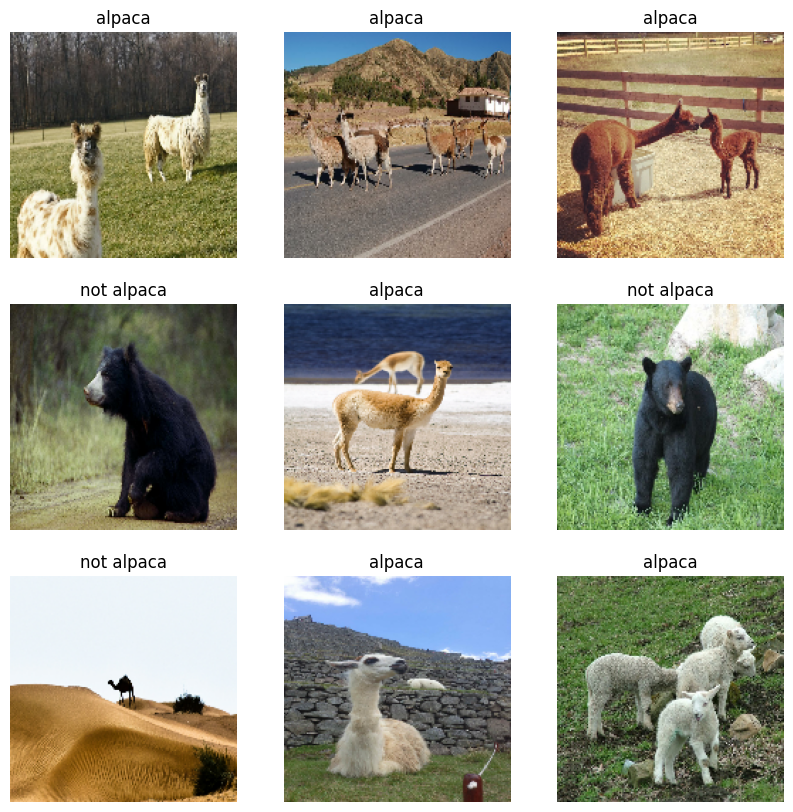

In [5]:
# --- 1. 原始图像样本可视化 ---
class_names = train_dataset.class_names
plt.figure(figsize=(10, 10))

# 从训练集中提取一个批次 (take(1)) 进行展示
for images, labels in train_dataset.take(1):
    for i in range(9):
        plt.subplot(3, 3, i+1)
        # 将张量转化为 uint8 格式以适配绘图要求
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]])
        plt.axis('off')
plt.show()

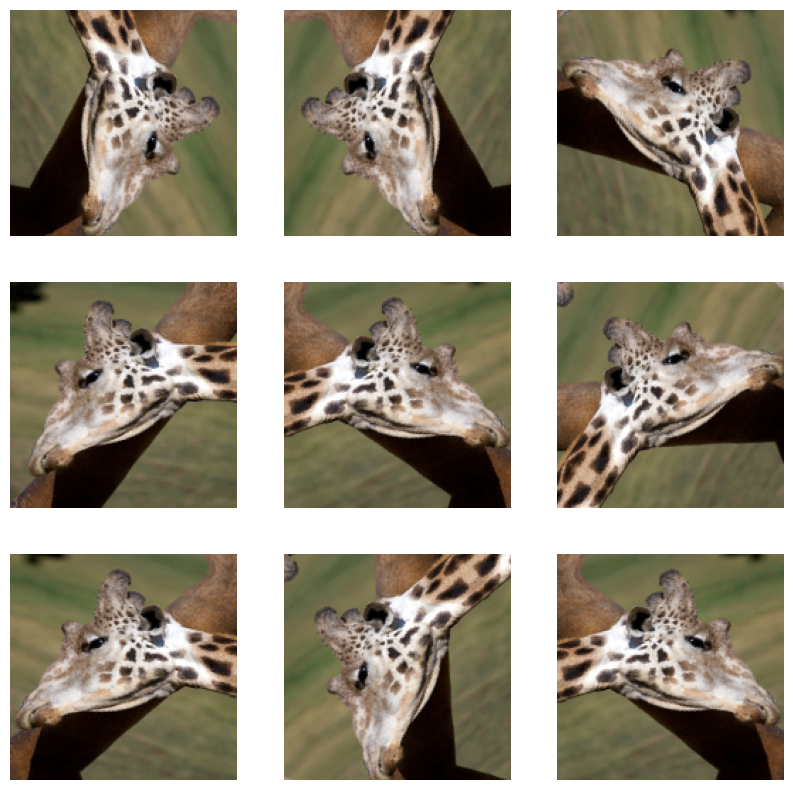

In [6]:
# --- 2. 配置数据管道优化与增强层 ---
# 开启预取机制，利用 CPU 并行预加载数据，减少显卡等待时间
# （tf.data.experimental.AUTOTUNE 已弃用，推荐 tf.data.AUTOTUNE）
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)

def data_augmenter():
    """构建数据增强序列层"""
    data_aug = Sequential()
    data_aug.add(RandomFlip('horizontal'))  # 模拟左右镜像对称
    data_aug.add(RandomRotation(0.2))       # 随机旋转（±20%幅度）
    return data_aug

data_augmentation = data_augmenter()

# --- 3. 增强效果对比演示 ---
# 选取一张图像，展示经过增强层后产生的 9 种随机变体
for images, _ in train_dataset.take(1):
    plt.figure(figsize=(10, 10))
    first_image = images[0]
    for i in range(9):
        plt.subplot(3, 3, i+1)
        # 将单张图升维后喂入增强层，再降维展示
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
        # 归一化至 [0, 1] 区间以便 matplotlib 渲染
        plt.imshow(augmented_image[0]/255.0)
        plt.axis('off')

In [7]:
# --- 1. 配置模型输入与预处理流水线 ---
# 调用 MobileNetV2 官方预处理函数（将像素映射至 [-1, 1]）
preprocess_input = keras.applications.mobilenet_v2.preprocess_input

# 定义输入张量形状：(160, 160, 3)
IMG_SHAPE = IMG_SIZE + (3,)

# --- 2. 加载完整的预训练 MobileNetV2 ---
# weights='imagenet' 表示加载在海量图像上训练好的权重
# include_top=True 会保留原始的 1000 类分类头，方便我们查看完整拓扑
base_model = keras.applications.MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=True,
    weights='imagenet')

# --- 3. 架构深度复盘 ---
# 打印模型摘要，重点观察层数与参数量的平衡
base_model.summary()

Model: "mobilenetv2_1.00_160"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 80, 80,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 80, 80,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 80, 80,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 80, 80,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 80, 80,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 80, 80,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 81, 81,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 40, 40,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 40, 40,    │      2,304 │ block_1_depthwis

 Total params: 3,538,984 (13.50 MB)

 Trainable params: 3,504,872 (13.37 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [8]:
# --- 1. 验证预训练基座的原始感知力 ---
# 提取一个批次数据并转为张量变量
image_batch, label_batch = next(iter(train_dataset))
image_var = tf.Variable(image_batch)

# 暂时锁定基座参数，观察其在原始 ImageNet 任务上的预测结果
base_model.trainable = False
pred = base_model(image_var)
# 解码预测：看看原始模型将这些羊驼看作了什么（通常是美洲驼或类似生物）
print("原始模型 Top-2 预测结果：", keras.applications.mobilenet_v2.decode_predictions(pred.numpy(), top=2))

# --- 2. 构建定制化的羊驼识别模型 ---
def alpaca_model(img_shape=IMG_SIZE, data_augmentation=data_augmenter()):
    input_shape = img_shape + (3,)
    # 加载不含分类头的基座 (include_top=False)
    base_model = keras.applications.MobileNetV2(input_shape=input_shape, include_top=False, weights="imagenet")
    # 核心步骤：冻结权重，只充当特征提取器
    base_model.trainable = False
    # 定义模型流水线
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)           # 应用随机数据增强
    x = preprocess_input(x)                 # 像素值归一化至 [-1, 1]
    # 提取特征：明确指定 training=False 确保 BatchNorm 状态稳定
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)  # 空间特征压缩
    x = layers.Dropout(0.2)(x)              # 增加正则化，防止过拟合
    # 针对二分类任务构建输出层 (Logits 输出)
    prediction_layer = layers.Dense(1)
    outputs = prediction_layer(x)
    return keras.Model(inputs, outputs)

# --- 3. 编译并启动初步训练 ---
my_alpaca = alpaca_model(IMG_SIZE, data_augmentation)
base_lr = 0.01  # 设定学习率
my_alpaca.compile(
    optimizer=keras.optimizers.Adam(learning_rate=base_lr),
    loss=keras.losses.BinaryCrossentropy(from_logits=True),  # 直接处理 Logits，数值稳定性更好
    metrics=['accuracy'])

initial_epochs = 5
# 启动 5 轮快速收敛训练
history = my_alpaca.fit(
    train_dataset,
    epochs=initial_epochs,
    validation_data=validation_dataset)

原始模型 Top-2 预测结果： [[('n04589890', 'window_screen', 0.42582268), ('n02708093', 'analog_clock', 0.09275501)], [('n04589890', 'window_screen', 0.23985858), ('n03887697', 'paper_towel', 0.14802569)], [('n04589890', 'window_screen', 0.74494517), ('n03598930', 'jigsaw_puzzle', 0.02194877)], [('n04589890', 'window_screen', 0.33546072), ('n03530642', 'honeycomb', 0.07628943)], [('n04589890', 'window_screen', 0.27327195), ('n03733281', 'maze', 0.08847001)], [('n04589890', 'window_screen', 0.6745234), ('n03530642', 'honeycomb', 0.076598905)], [('n04589890', 'window_screen', 0.79128414), ('n04209239', 'shower_curtain', 0.09241714)], [('n04589890', 'window_screen', 0.16463004), ('n03598930', 'jigsaw_puzzle', 0.087492)], [('n03598930', 'jigsaw_puzzle', 0.37021282), ('n04589890', 'window_screen', 0.099569514)], [('n04589890', 'window_screen', 0.61616695), ('n03887697', 'paper_towel', 0.054876342)], [('n03530642', 'honeycomb', 0.2544887), ('n04589890', 'window_screen', 0.24874312)], [('n04589890', 'wi

/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 185ms/step - accuracy: 0.6107 - loss: 0.8428 - val_accuracy: 0.9231 - val_loss: 0.2183
Epoch 2/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 0.8435 - loss: 0.3497 - val_accuracy: 0.9692 - val_loss: 0.1514
Epoch 3/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step - accuracy: 0.8817 - loss: 0.2481 - val_accuracy: 0.9692 - val_loss: 0.0966
Epoch 4/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.9275 - loss: 0.1786 - val_accuracy: 0.9692 - val_loss: 0.0872
Epoch 5/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.9008 - loss: 0.1694 - val_accuracy: 0.9692 - val_loss: 0.0832


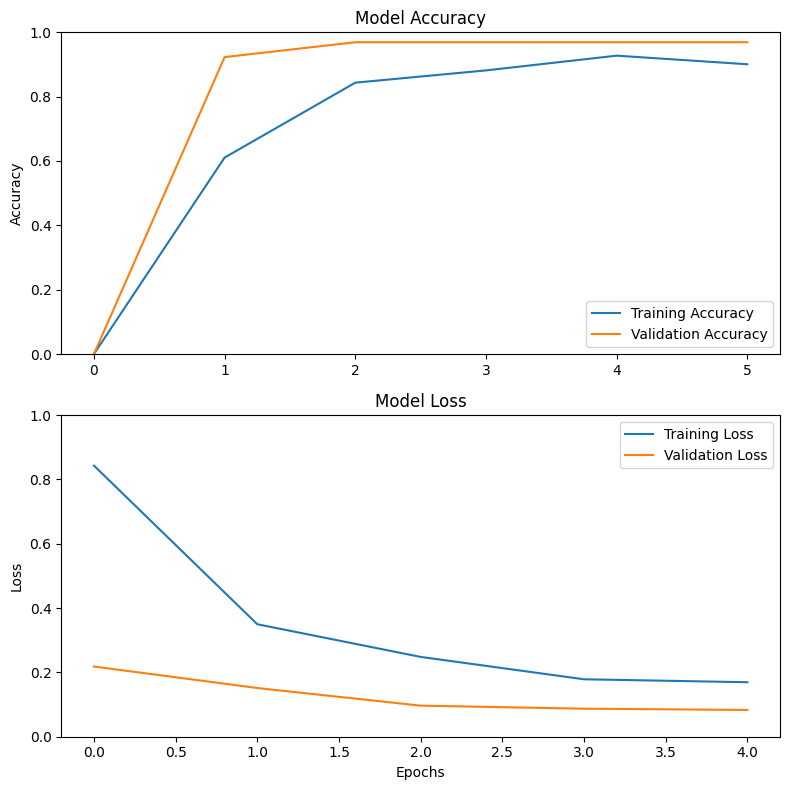

In [9]:
# --- 1. 提取训练历史指标 ---
# 补零以便从 0 轴开始观察增长趋势
acc = [0.] + history.history['accuracy']
val_acc = [0.] + history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# --- 2. 绘制双子图：准确率与损失值 ---
plt.figure(figsize=(8, 8))

# 子图 1：准确率对比
plt.subplot(2, 1, 1)
plt.plot(acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.ylabel("Accuracy")
plt.legend(loc='lower right')
plt.ylim([0, 1])  # 设定纵坐标范围，便于观察相对位置
plt.title("Model Accuracy")

# 子图 2：损失值对比
plt.subplot(2, 1, 2)
plt.plot(loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")
plt.ylabel("Loss")
plt.legend(loc='upper right')
plt.ylim([0, 1.0])
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.tight_layout()  # 自动调整子图间距，避免标签重叠
plt.show()